In [ ]:
import pandas as pd
data = pd.DataFrame({
     "Gene": ["GeneA", "GeneB", "GeneC"],
     "Sample1": [10, 5, 8],
     "Sample2": [12, 3, 9],
     "Sample3": [11, 4, 7]
     })
    

In [ ]:
data.describe()

,Sample1,Sample2,Sample3
count,3.000000,3.000000,3.000000
mean,7.666667,8.000000,7.333333
std,2.516611,4.582576,3.511885
min,5.000000,3.000000,4.000000
25%,6.500000,6.000000,5.500000
50%,8.000000,9.000000,7.000000
75%,9.000000,10.500000,9.000000
max,10.000000,12.000000,11.000000


In [ ]:
data_long = data.melt(id_vars="Gene", var_name="Sample", value_name="Expression")


In [ ]:
import sys 
!{sys.executable} -m pip install matplotlib seaborn pandas

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

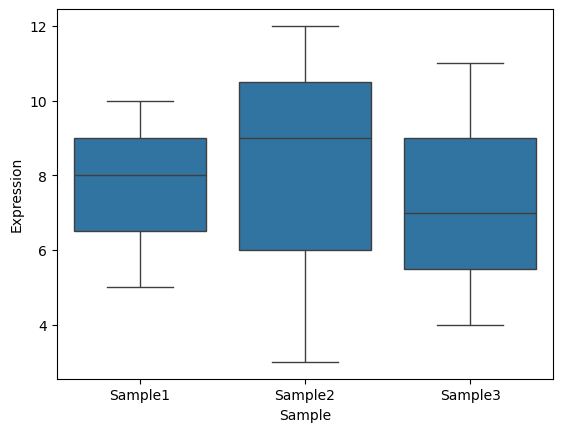

In [ ]:
sns.boxplot(data=data_long, x="Sample", y="Expression")
plt.show()

also installing the dependencies ‘farver’, ‘labeling’, ‘RColorBrewer’, ‘viridisLite’, ‘gtable’, ‘isoband’, ‘S7’, ‘scales’



trying URL 'https://cran.rstudio.com/bin/macosx/big-sur-arm64/contrib/4.5/farver_2.1.2.tgz'
trying URL 'https://cran.rstudio.com/bin/macosx/big-sur-arm64/contrib/4.5/labeling_0.4.3.tgz'
trying URL 'https://cran.rstudio.com/bin/macosx/big-sur-arm64/contrib/4.5/RColorBrewer_1.1-3.tgz'
trying URL 'https://cran.rstudio.com/bin/macosx/big-sur-arm64/contrib/4.5/viridisLite_0.4.3.tgz'
trying URL 'https://cran.rstudio.com/bin/macosx/big-sur-arm64/contrib/4.5/gtable_0.3.6.tgz'
trying URL 'https://cran.rstudio.com/bin/macosx/big-sur-arm64/contrib/4.5/isoband_0.3.0.tgz'
trying URL 'https://cran.rstudio.com/bin/macosx/big-sur-arm64/contrib/4.5/S7_0.2.1.tgz'
trying URL 'https://cran.rstudio.com/bin/macosx/big-sur-arm64/contrib/4.5/scales_1.4.0.tgz'
trying URL 'https://cran.rstudio.com/bin/macosx/big-sur-arm64/contrib/4.5/tidyr_1.3.2.tgz'
trying URL 'https://cran.rstudio.com/bin/macosx/big-sur-arm64/contrib/4.5/ggplot2_4.0.2.tgz'
trying URL 'https://cran.rstudio.com/bin/macosx/big-sur-arm64/contrib/


The downloaded binary packages are in
	/var/folders/sm/6qxk0z3n7hd11l51ht3k0g980000gn/T//RtmpqPq3Cn/downloaded_packages


Warning message:
package ‘ggplot2’ was built under R version 4.5.2 


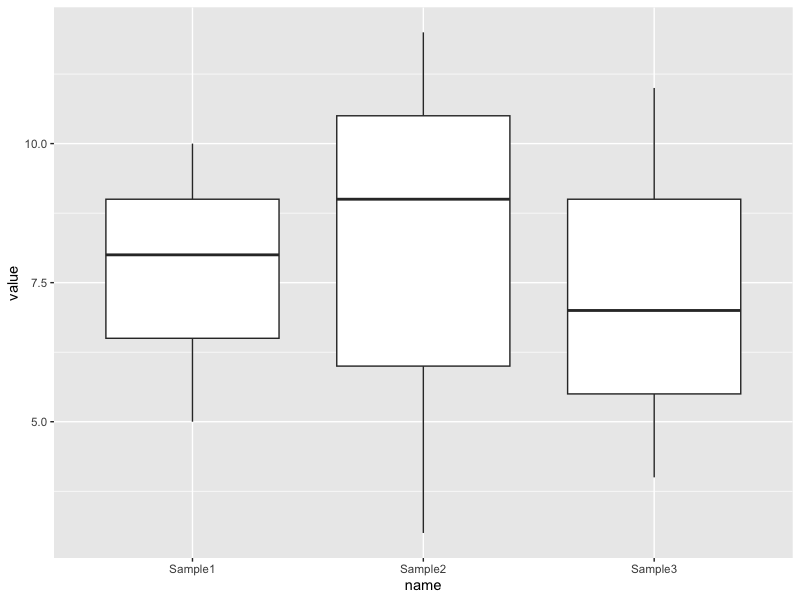

In [ ]:


c

In [9]:

data <- data.frame(
    Gene = c("GeneA", "GeneB", "GeneC"),
    Sample1 = c(10,5,8),
    Sample2 = c(12,3,9),
    Sample3 = c(11,4,7)
)
library(tidyr)
data_long <- pivot_longer(data, -Gene)

aggregate(value ~ name, data=data_long, mean)

     name    value
1 Sample1 7.666667
2 Sample2 8.000000
3 Sample3 7.333333

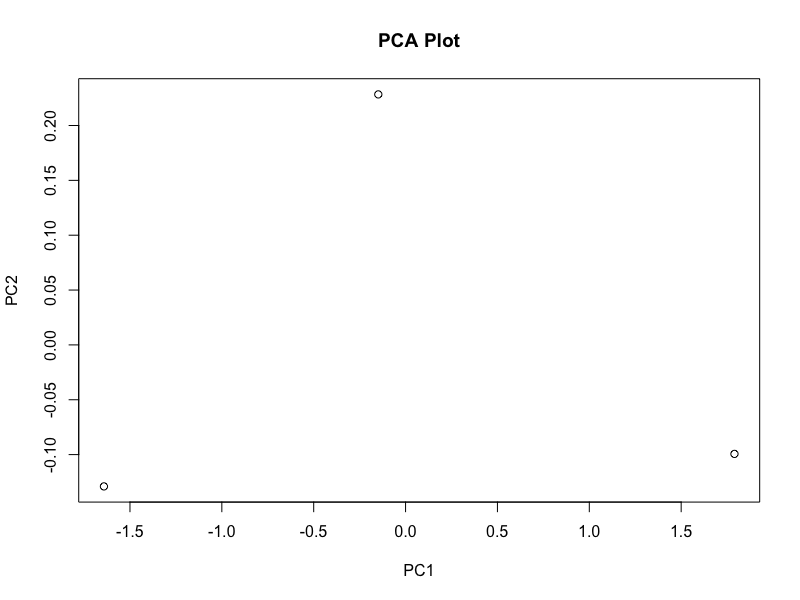

In [12]:
data_matrix <- data[, -1]
pca <- prcomp(data_matrix, scale.=TRUE)
plot(pca$x[,1], pca$x[,2],
    xlab="PC1",
  ylab="PC2",
main="PCA Plot")


In [14]:
# PCA jeder Punkt ein Sample - weit auseinander = Unterschiede 
# PC1 = größte Variation - trennt Samples nach dem stärksten Muster 
# PC2 = zweitgrößte Variation - zeigt zweitstärkstes Muster
# Achsen sind Mischungen vielen Gene 
# Omics zu viel Gene dehalb vorab dieses Muster 
# Man sieht: Gruppen, Außreißer, Trends, Batch-Effekte
# Prüfbar: trennen sich krank/gesund?, Ausreißer?, clustern Replikate zusammen?, technische Effekte?
# PCA = Überblicksplot für Ähnlichkeit und Unterschied 


In [15]:
# PHASE 2 DATENBEREINIGUNG

In [16]:
data_dirty <- data.frame(
  Gene = c("GeneA", "GeneB", "GeneC", "GeneD"), 
  Sample1 = c(10, NA, 8, 1000),
  Sample2 = c(12, 3, NA, 9), 
  Sample3 = c(11, 4, 7, "error") 
)
str(data_dirty)

'data.frame':	4 obs. of  4 variables:
 $ Gene   : chr  "GeneA" "GeneB" "GeneC" "GeneD"
 $ Sample1: num  10 NA 8 1000
 $ Sample2: num  12 3 NA 9
 $ Sample3: chr  "11" "4" "7" "error"


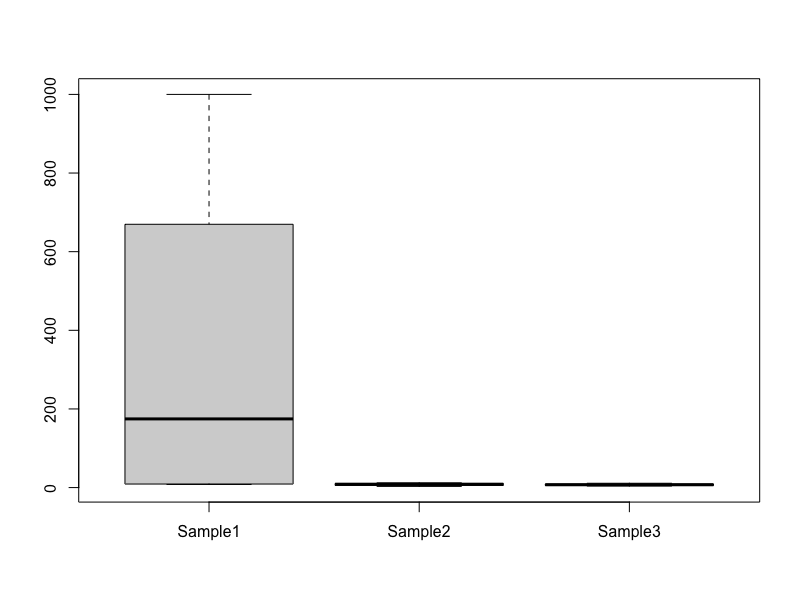

In [ ]:
# Fehelr beheben = Datenreinigung 

data_dirty[data_dirty == "error"] <- NA
data_dirty[, -1] <- lapply(data_dirty[, -1], as.numeric)
colSums(is.na(data_dirty))
data_clean <- data_dirty
for(i in 2:ncol(data_clean)){
  data_clean[is.na(data_clean[,i]), i] <- mean(data_clean[,i], na.rm=TRUE)
  }
boxplot(data_clean[, -1])

# Zeigt im Plot, dass 1000 unrealistisch ist 

In [ ]:
data_clean <- data_clean[data_clean$Sample1 < 100, ]

# Richitge Größe


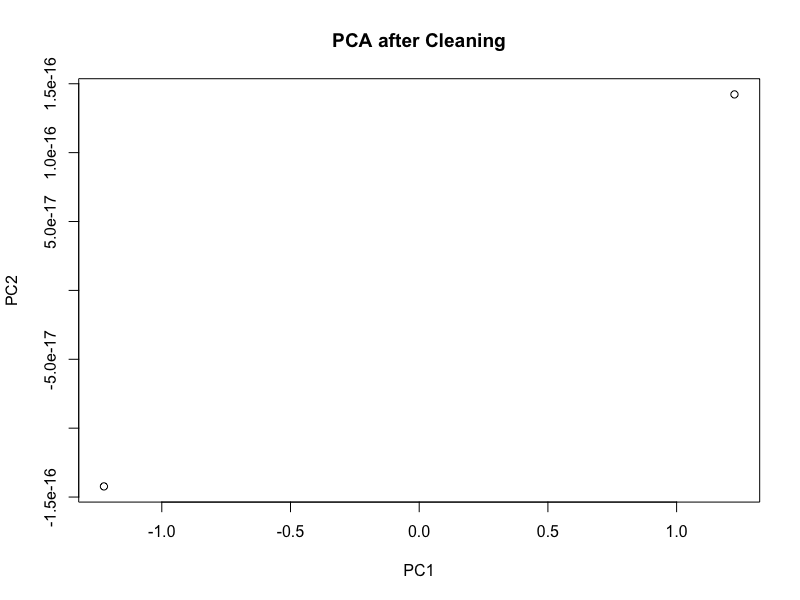

In [25]:
# PHASE 3: ECHTE ANALYSE
# Schritt 1: PCA

data_matrix <- data_clean[, -1]
pca <- prcomp(data_matrix, scale.=TRUE)
plot(pca$x[,1], pca$x[,2],
    xlab="PC1", ylab="PC2",
    main="PCA after Cleaning")

In [26]:
heatmap(data_matrix)

: [1m[33mError[39m in `heatmap()`:[22m
[33m![39m 'x' must be a numeric matrix

In [27]:
install.packages(epipot)


: [1m[33mError[39m:[22m
[33m![39m object 'epipot' not found

In [28]:
as.table.default()

: [1m[33mError[39m in `as.table.default()`:[22m
[33m![39m argument "x" is missing, with no default

In [29]:
TBD

: [1m[33mError[39m:[22m
[33m![39m object 'TBD' not found